## EDA by Philipp

In [1]:
# Import the relevant modules and classes
from data_loaders import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy



# Create a dataloader instance
data = DataLoader()

## Price data

Day Ahead Price Data:
Index(['date', 'Day-ahead price (EUR/MWh)'], dtype='str')

                       date  Day-ahead price (EUR/MWh)
0 2015-01-01 00:00:00+00:00                      27.07
1 2015-01-01 01:00:00+00:00                      26.93
2 2015-01-01 02:00:00+00:00                      26.83
3 2015-01-01 03:00:00+00:00                      26.81
4 2015-01-01 04:00:00+00:00                      26.97

       Day-ahead price (EUR/MWh)
count              103062.000000
mean                   59.492173
std                    67.356150
min                   -61.840000
25%                    25.360000
50%                    40.770000
75%                    69.080000
max                   898.250000


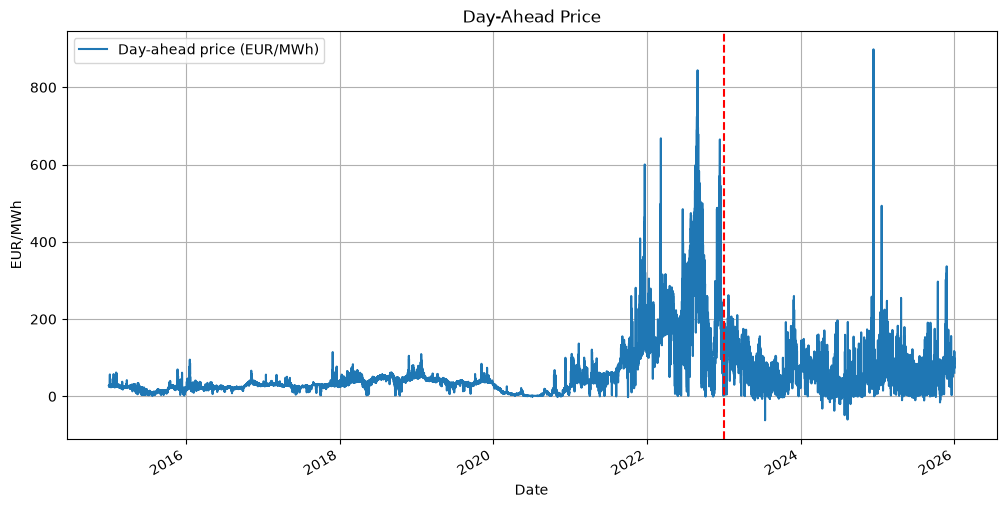

Interval between timestamps in the day ahead price data:
Minimum interval: 0 days 00:15:00
Maximum interval: 0 days 01:00:00
Mean interval: 0 days 00:56:08.435198


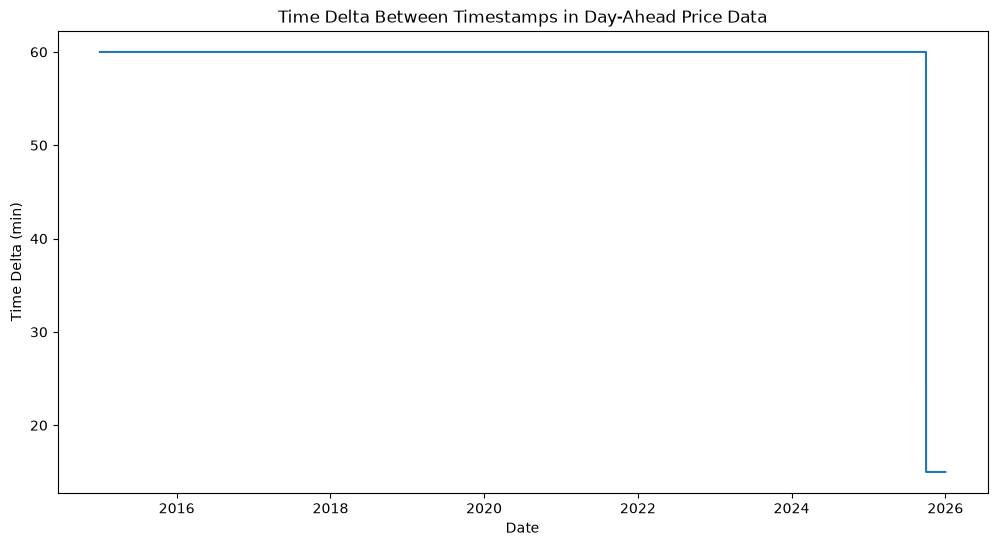

In [2]:
# plot the day ahead price data
print("Day Ahead Price Data:")
print(data.day_ahead_price_data.columns)
print()
print(data.day_ahead_price_data.head())
print()
print(data.day_ahead_price_data.describe())

data.day_ahead_price_data = data.day_ahead_price_data.sort_values('date')

# Generate the plot
data.day_ahead_price_data.plot(x='date', y='Day-ahead price (EUR/MWh)', figsize=(12, 6))
plt.title('Day-Ahead Price')
plt.ylabel('EUR/MWh')
plt.xlabel('Date')

# Add vertical line until December 31 2022
plt.axvline(pd.Timestamp('2023-01-01 00:00:00'), color='red', linestyle='--', label='End of 2022')

plt.grid(True)
plt.show()


# Check interval between timestamps in the day ahead price data
print("Interval between timestamps in the day ahead price data:")
print(f"Minimum interval: {data.day_ahead_price_data['date'].diff().min()}")
print(f"Maximum interval: {data.day_ahead_price_data['date'].diff().max()}")
print(f"Mean interval: {data.day_ahead_price_data['date'].diff().mean()}")


# Calculate time delta
data.day_ahead_price_data['time_delta'] = data.day_ahead_price_data['date'].diff().dt.total_seconds() / 60

# Drop the first NaT value for plotting
plot_data = data.day_ahead_price_data.dropna(subset=['time_delta'])

plt.figure(figsize=(12, 6))
# Use plot_data instead of data.day_ahead_price_data
plt.plot(plot_data['date'], plot_data['time_delta'], linestyle='-')
plt.title('Time Delta Between Timestamps in Day-Ahead Price Data')
plt.ylabel('Time Delta (min)')
plt.xlabel('Date')
plt.show()

## Inflow data

Inflow Data:
Index(['date', 'Langesae', 'Staavatn', 'Kjelavatn', 'Bordalsvatn', 'Foersvatn',
       'Hyljelihyl', 'Venemo', 'Bitdalsvatn', 'Songavatn', 'Totak',
       'Vaamarvatn', 'Langeidvatn', 'Vatjern', 'Vinjevatn', 'Botnedalsvatn',
       'Byrtevatn', 'Bandak', 'r_Vest_Vassdraget'],
      dtype='str')

                       date  Langesae  Staavatn  Kjelavatn  Bordalsvatn  \
0 1958-01-01 00:00:00+00:00      0.37      0.03       1.23          0.5   
1 1958-01-01 01:00:00+00:00      0.37      0.03       1.23          0.5   
2 1958-01-01 02:00:00+00:00      0.37      0.03       1.23          0.5   
3 1958-01-01 03:00:00+00:00      0.37      0.03       1.23          0.5   
4 1958-01-01 04:00:00+00:00      0.37      0.03       1.23          0.5   

   Foersvatn  Hyljelihyl  Venemo  Bitdalsvatn  Songavatn  Totak  Vaamarvatn  \
0       0.05        0.34    0.37         1.07       4.92   3.28        0.21   
1       0.05        0.34    0.37         1.07       4.92   3.28        0.21   
2 

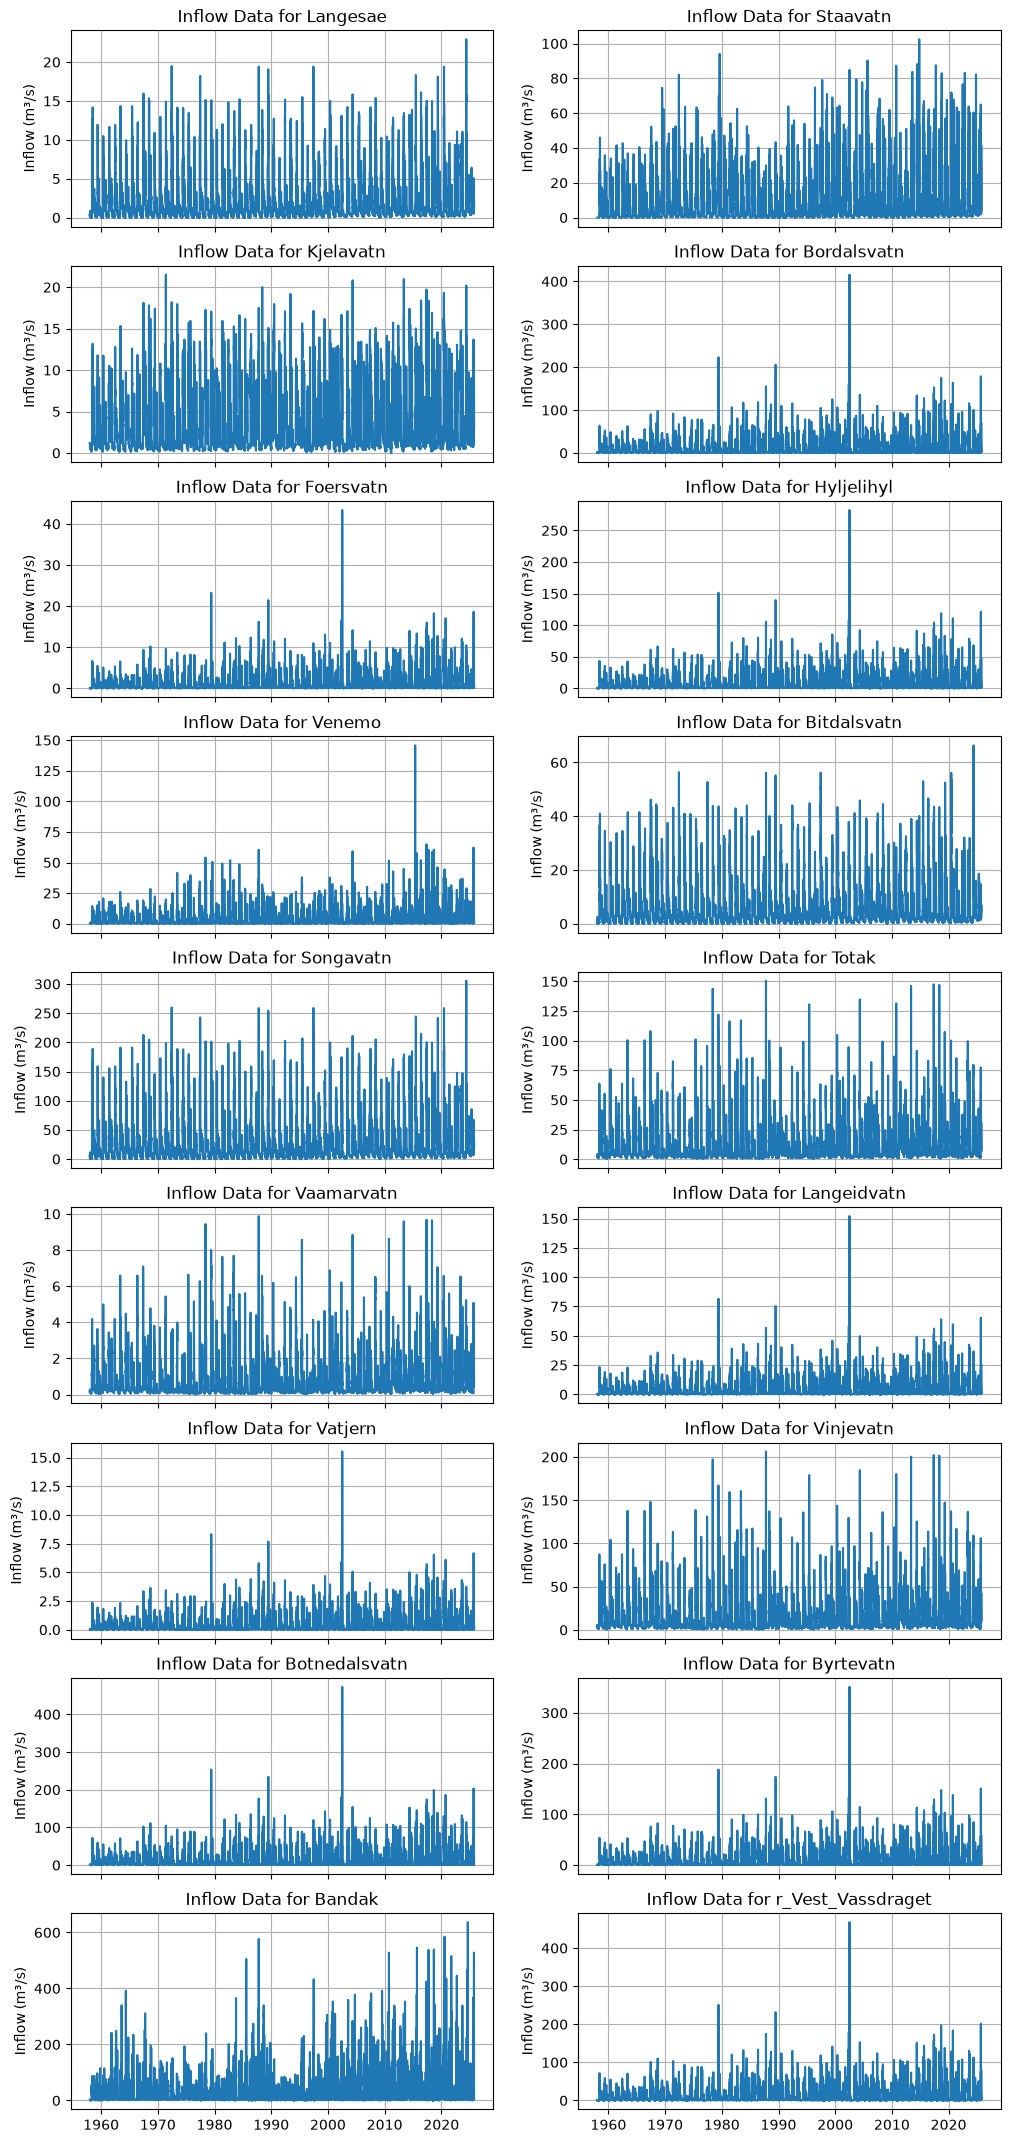

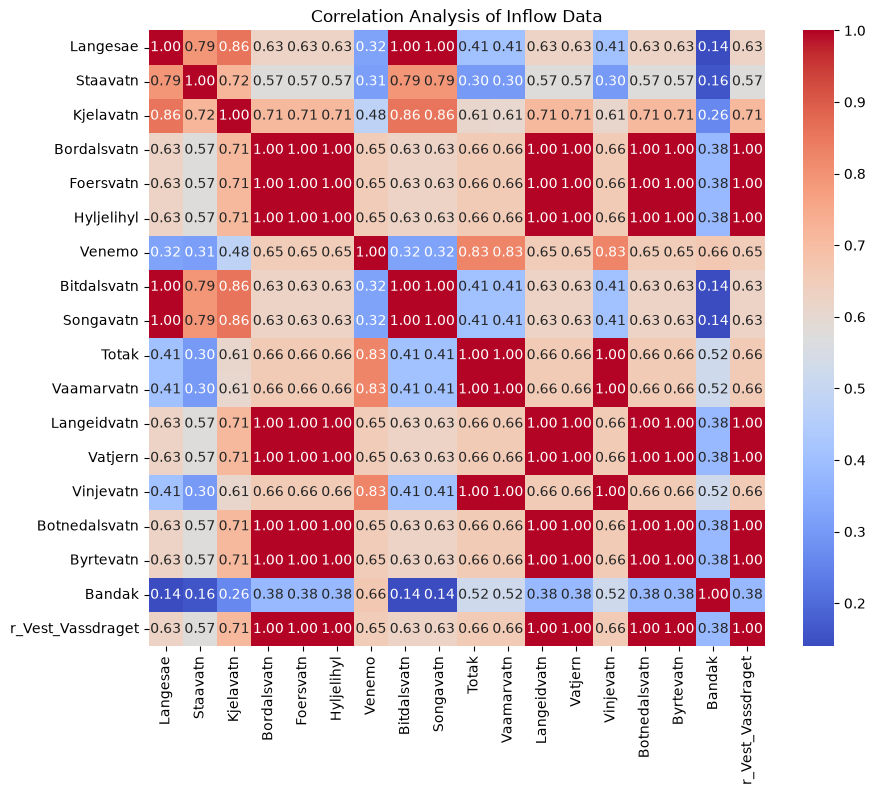

In [3]:
print("Inflow Data:")
print(data.inflow_data.columns)
print()
print(data.inflow_data.head())
print()
print(data.inflow_data.describe())


# Plot all inflow columns in one diagram
columns = data.inflow_data.columns.drop('date')
# Calculate rows for 2 columns and flatten the 2D axes array
nrows = (len(columns) + 1) // 2
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 3 * nrows), sharex=True)
axes = axes.flatten()

# Iterate with index to hide empty subplots for odd column counts
for i, ax in enumerate(axes):
    if i < len(columns):
        column = columns[i]
        ax.plot(data.inflow_data['date'], data.inflow_data[column], linestyle='-')
        ax.set_title(f'Inflow Data for {column}')
        ax.set_ylabel('Inflow (m³/s)')
        ax.grid(True)
    else:
        fig.delaxes(ax)

# Calculate correlation and plot heatmap
correlation_matrix = data.inflow_data[columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Analysis of Inflow Data')
plt.show()


## Volume Analysis

Volume Data:
Index(['date', 'Kjelavatn', 'Staavatn', 'Langesae', 'Foersvatn', 'Venemo',
       'Botnedalsvatn', 'Bitdalsvatn', 'Vaamarvatn', 'Langeidvatn', 'Totak',
       'Songavatn', 'Vinjevatn', 'Bandak', 'Bordalsvatn', 'Byrtevatn',
       'Hyljelihyl', 'Vatjern'],
      dtype='str')

                       date  Kjelavatn  Staavatn  Langesae  Foersvatn  Venemo  \
0 2015-01-01 00:00:00+00:00     42.352    17.472    56.669     92.150  18.263   
1 2015-01-02 00:00:00+00:00     42.001    16.474    56.262     92.185  18.332   
2 2015-01-03 00:00:00+00:00     41.494    15.360    55.753     92.079  18.356   
3 2015-01-04 00:00:00+00:00     41.221    14.784    55.516     91.938  18.388   
4 2015-01-05 00:00:00+00:00     41.182    14.630    55.482     91.903  18.388   

   Botnedalsvatn  Bitdalsvatn  Vaamarvatn  Langeidvatn    Totak  Songavatn  \
0         32.999       92.404       9.796       30.541  170.219    492.379   
1         32.999       92.024      11.079       30.587  170.219    4

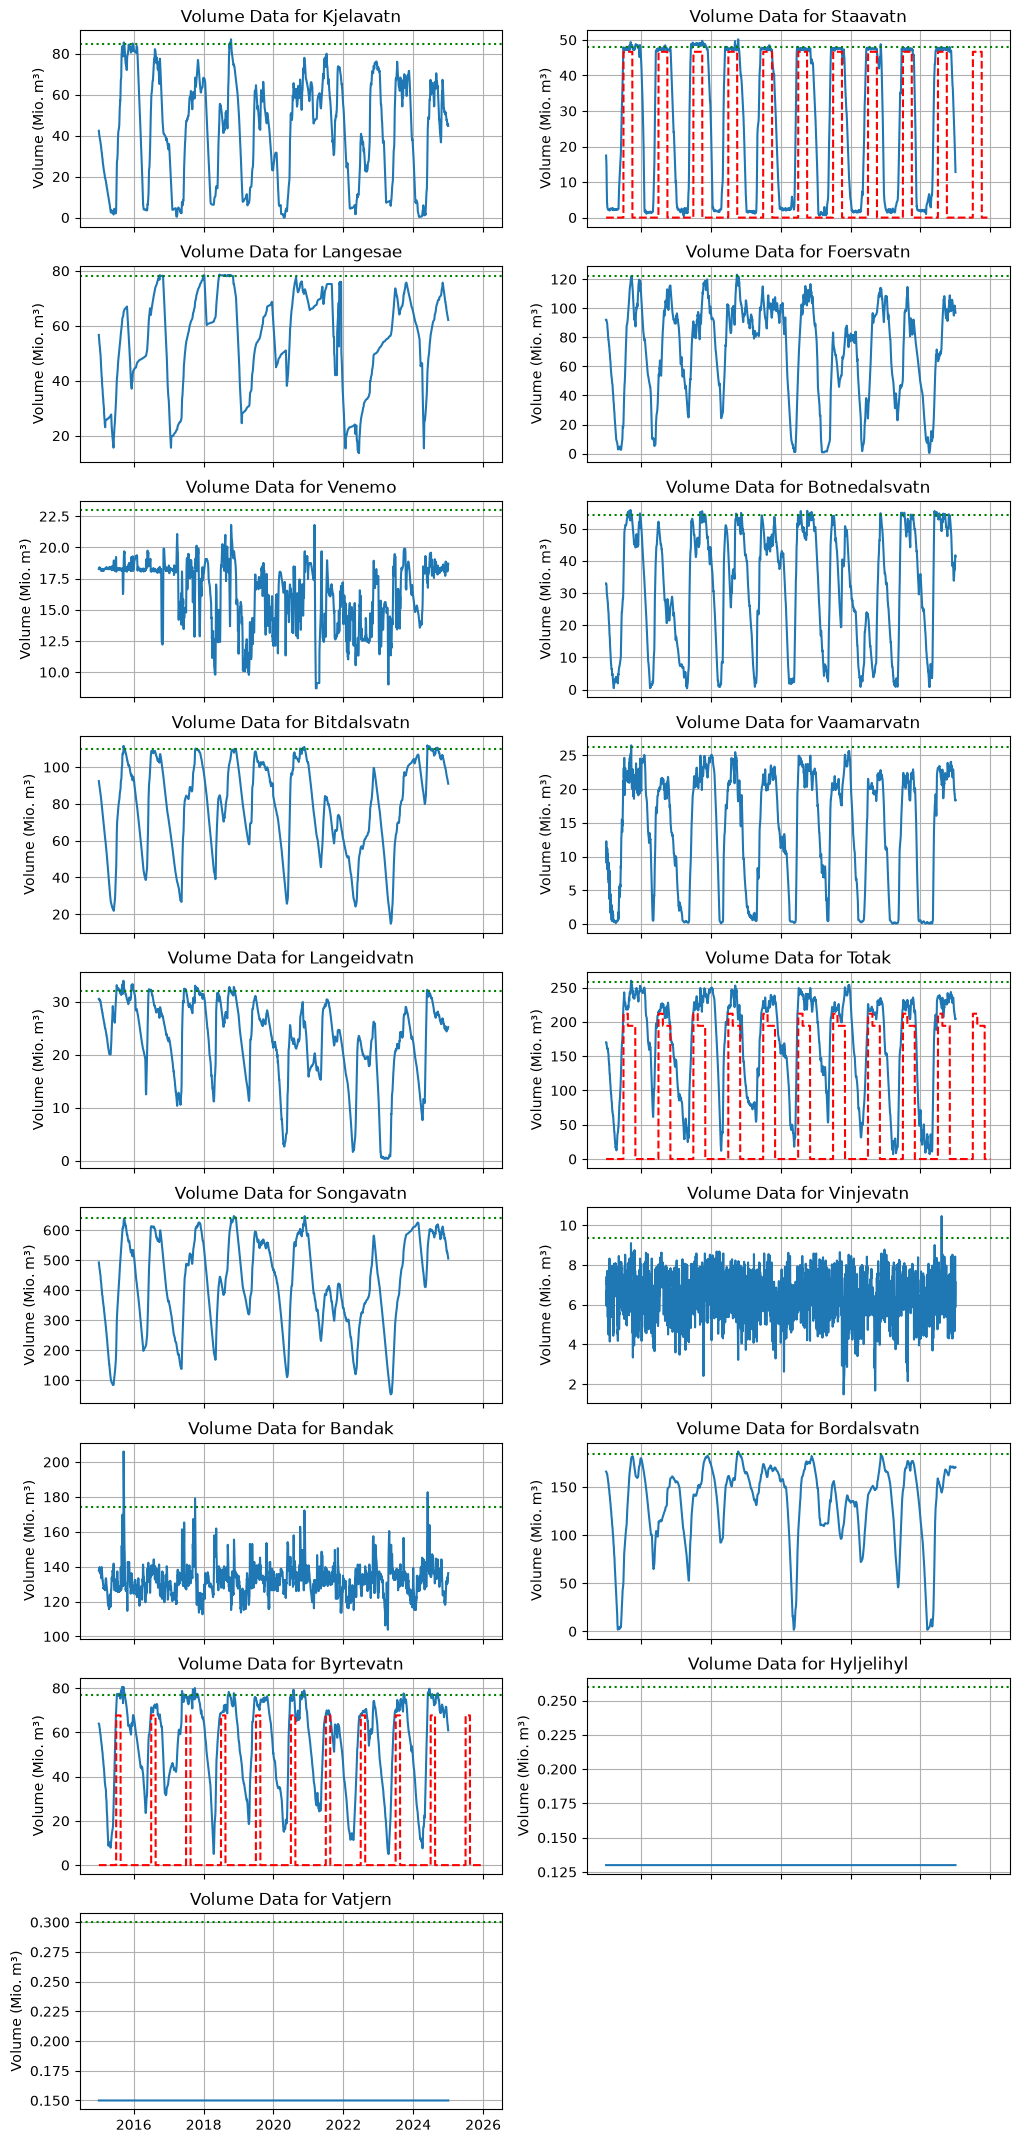

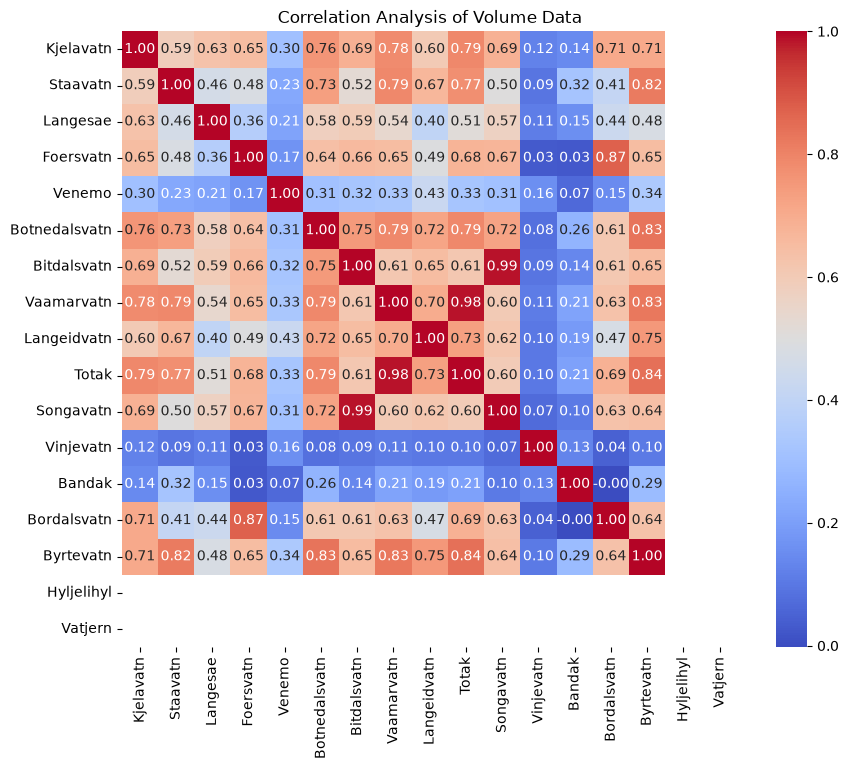

In [4]:
print("Volume Data:")
print(data.volume_data.columns)
print()
print(data.volume_data.head())
print()
print(data.volume_data.describe())

print("Minimum Volume Constraint Data:")
print(data.min_volume_constraint_data.columns)
print()
print(data.min_volume_constraint_data.head())
print()
print(data.min_volume_constraint_data.describe())



# Plot all volume columns in one diagram
columns = data.volume_data.columns.drop('date')
# Calculate rows for 2 columns and flatten the 2D axes array
nrows = (len(columns) + 1) // 2
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 3 * nrows), sharex=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(columns):
        column = columns[i]
        ax.plot(data.volume_data['date'], data.volume_data[column], linestyle='-')
        
        if column in data.min_volume_constraint_data.columns:
            ax.plot(data.min_volume_constraint_data['date'], data.min_volume_constraint_data[column], linestyle='--', color='red')
            
        # Plot maximum volume constraint
        if column in data.topology_data['model']['reservoir']:
            max_vol = data.topology_data['model']['reservoir'][column]['max_vol']
            ax.axhline(y=max_vol, linestyle=':', color='green')
            
        ax.set_title(f'Volume Data for {column}')
        ax.set_ylabel('Volume (Mio. m³)')
        ax.grid(True)
    else:
        fig.delaxes(ax)


# TODO: Add maximum volume constraints data in the plot



# Calculate correlation and plot heatmap
correlation_matrix = data.volume_data[columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Analysis of Volume Data')
plt.show()

## Synthetic Water Value

Synthetic Water value Data:
Index(['date', 'Kjelavatn', 'Staavatn', 'Langesae', 'Foersvatn', 'Venemo',
       'Botnedalsvatn', 'Bitdalsvatn', 'Vaamarvatn', 'Langeidvatn', 'Totak',
       'Songavatn', 'Vinjevatn', 'Bandak', 'Bordalsvatn', 'Byrtevatn',
       'Hyljelihyl', 'Vatjern'],
      dtype='str')

                       date  Kjelavatn  Staavatn  Langesae  Foersvatn  Venemo  \
0 2015-01-01 00:00:00+00:00      40.49     40.49     31.81      31.81   28.98   
1 2015-01-02 00:00:00+00:00      40.89     40.89     30.96      30.96   26.44   
2 2015-01-03 00:00:00+00:00      40.87     40.87     30.51      30.51   26.36   
3 2015-01-04 00:00:00+00:00      40.50     40.50     30.06      30.06   26.33   
4 2015-01-05 00:00:00+00:00      39.51     39.51     29.35      29.35   26.06   

   Botnedalsvatn  Bitdalsvatn  Vaamarvatn  Langeidvatn  Totak  Songavatn  \
0          38.70        30.13       28.98         4.78  28.98      30.13   
1          36.47        30.52       26.44         4.44  2

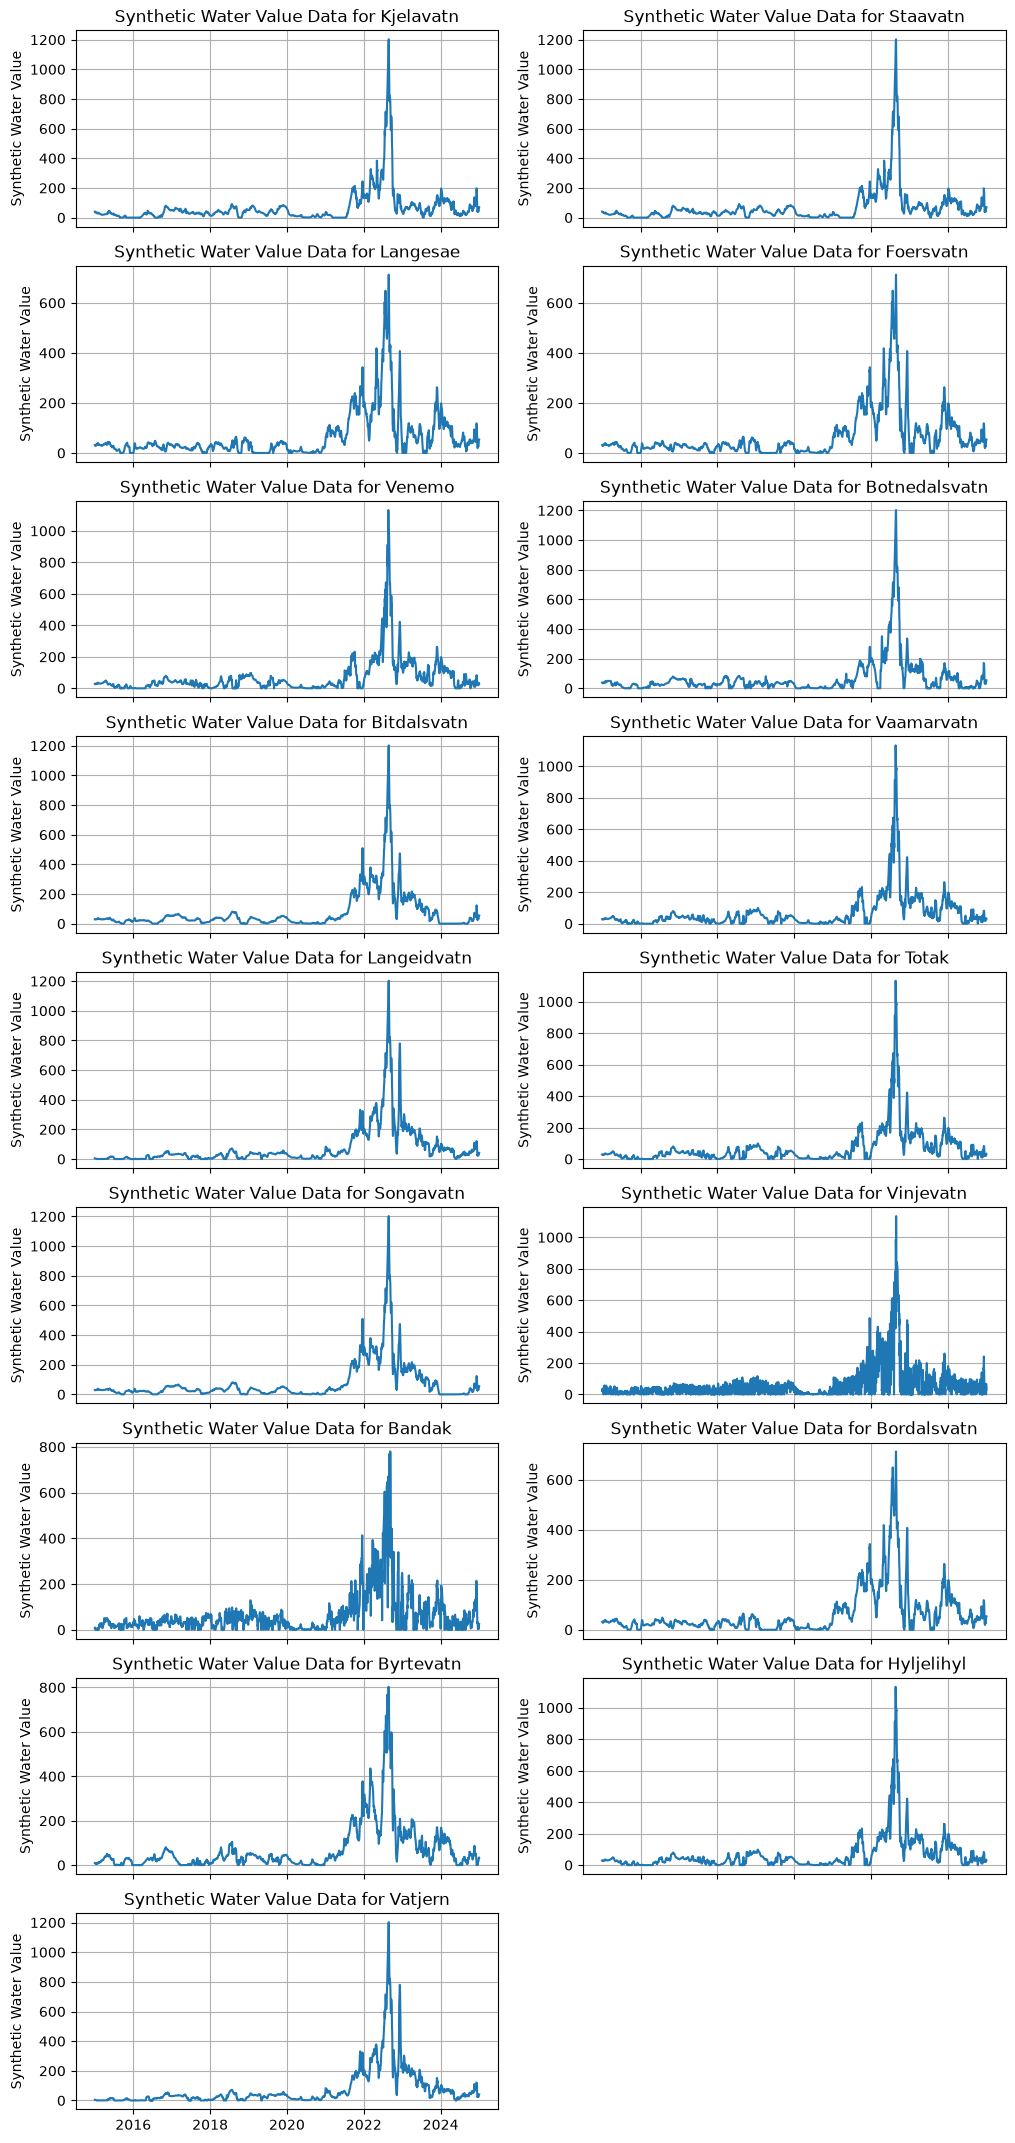

In [5]:
print("Synthetic Water value Data:")
print(data.synthetic_water_value_data.columns)
print()
print(data.synthetic_water_value_data.head())
print()
print(data.synthetic_water_value_data.describe())


# Plot all inflow columns in one diagram
columns = data.synthetic_water_value_data.columns.drop('date')
# Calculate rows for 2 columns and flatten the 2D axes array
nrows = (len(columns) + 1) // 2
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 3 * nrows), sharex=True)
axes = axes.flatten()

# Iterate with index to hide empty subplots for odd column counts
for i, ax in enumerate(axes):
    if i < len(columns):
        column = columns[i]
        ax.plot(data.synthetic_water_value_data['date'], data.synthetic_water_value_data[column], linestyle='-')
        ax.set_title(f'Synthetic Water Value Data for {column}')
        ax.set_ylabel('Synthetic Water Value')
        ax.grid(True)
    else:
        fig.delaxes(ax)



## Commitment Decision

In [6]:
print("Commitment Decision Data:")
print(data.commitment_decision_data.columns)
print()
print(data.commitment_decision_data.head())
print()
print(data.commitment_decision_data.describe())


Commitment Decision Data:
Index(['Run No', 'starttime', 'total_calculation_time',
       'result_committed_Hogga_G1_t0', 'result_committed_Hogga_G1_t1',
       'result_committed_Hogga_G1_t2', 'result_committed_Hogga_G1_t3',
       'result_committed_Hogga_G1_t4', 'result_committed_Hogga_G1_t5',
       'result_committed_Hogga_G1_t6',
       ...
       'result_committed_Vesle Kjela_G1_t158',
       'result_committed_Vesle Kjela_G1_t159',
       'result_committed_Vesle Kjela_G1_t160',
       'result_committed_Vesle Kjela_G1_t161',
       'result_committed_Vesle Kjela_G1_t162',
       'result_committed_Vesle Kjela_G1_t163',
       'result_committed_Vesle Kjela_G1_t164',
       'result_committed_Vesle Kjela_G1_t165',
       'result_committed_Vesle Kjela_G1_t166',
       'result_committed_Vesle Kjela_G1_t167'],
      dtype='str', length=2355)

   Run No  starttime  total_calculation_time  result_committed_Hogga_G1_t0  \
0       1 2015-01-01               48.950692                             

The prediction is a rolling horizon prediction where each new day a new prediction is made for the next week 168 hours. The data until Run No 2922 can be used within the training of the model. The later data (2923-3647) will be used for the kaggle test. That data will need to be uploaded to kaggle to be tested there.




